In [1]:
import hoda
import tensorly as tl
import mne

mne.set_log_level('ERROR')
tl.set_backend('numpy')
tl.get_backend()

'numpy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=64, tmin=-0.2)
dataset = BNCI2014_008()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
#session = meta['session'][0]
#idc = meta['session'] == session
#epochs = epochs[idc]
#labels = labels[idc]
#meta = meta[idc]

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs |  4200 events (all good), -0.199219 – 1 s, baseline off, ~79.0 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np

nfreqs=16

X = epochs.get_data()
X = tl.tensor(X)
y = labels

X.shape

(4200, 8, 77)

In [23]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[[8,77]],
    hoda_params=dict(
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        forward=False,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=False,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X,y)

Fitting block 1/1...


Forward model :   0%|          | 1/256 [00:00<00:30,  8.26it/s]


CPU times: user 1min 33s, sys: 3.18 s, total: 1min 36s
Wall time: 12.1 s


BTTDA(hoda_params={'extra_train_info': False, 'forward': False,
                   'init': 'random', 'max_iter': 256, 'obj': 'tr',
                   'random_state': 42, 'rank': [8, 77], 'shrinkage': 'lw',
                   'solver': 'lanczos', 'taper': True, 'toeplitz': None,
                   'tol': 1e-12, 'verbose': True},
      ranks=[[8, 77]], verbose=True)

In [24]:
Xt.shape


(4200, 16)

In [25]:
Xt = bttda.transform(X)
Xt = tl.to_numpy(Xt)

In [26]:
from sklearn.feature_selection import f_classif
f,p = f_classif(Xt,y)
p

array([7.71376097e-01, 1.35439749e-01, 9.10930584e-01, 7.62093586e-01,
       4.17896267e-01, 9.94077600e-01, 1.53453764e-01, 6.84076963e-01,
       5.18421860e-01, 2.14976874e-01, 7.53912370e-02, 5.45342200e-01,
       3.85702963e-01, 5.80527761e-02, 3.09959871e-01, 9.95291721e-01,
       5.72255412e-01, 3.27040957e-01, 3.29730599e-01, 7.30836539e-01,
       1.23925244e-01, 7.76667371e-01, 7.32364997e-01, 7.37931721e-02,
       1.59049257e-01, 3.29421386e-01, 9.21675879e-01, 6.28345549e-01,
       9.34559035e-01, 1.17511312e-01, 8.77147914e-03, 6.20968737e-02,
       2.48366000e-01, 2.63393005e-01, 2.09602366e-01, 9.20157753e-01,
       9.76868646e-02, 3.93179593e-03, 2.97381848e-01, 2.27288440e-02,
       3.07509076e-01, 2.60024238e-03, 6.50629553e-02, 4.20377397e-04,
       1.19862911e-03, 6.33432608e-01, 8.49098900e-01, 4.60981808e-01,
       6.09439844e-01, 4.19864220e-01, 1.31582526e-01, 9.74728552e-01,
       6.59479263e-01, 4.04112964e-01, 6.99717922e-01, 3.22359334e-01,
      

In [5]:
import numpy as np
np.any(np.isnan(bttda.transform(X)))

False

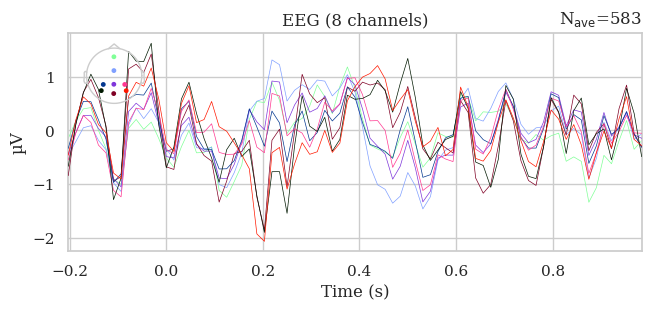

FileExistsError: Destination file exists. Please use option "overwrite=True" to force overwriting.

In [6]:
from mne import combine_evoked
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])
contrast.plot()
contrast.save('forward/contrast.fif')

In [ ]:
import math
from mne import EvokedArray
Xt = bttda.transform(X)
i = 0
classes = np.unique(y)
fig, axs = plt.subplots(bttda.n_blocks_,4, sharey='col')
for b, block in enumerate(bttda.blocks_):
    n_features = math.prod(block.rank_)
    Xtb = Xt[:,i:i+n_features]
    Xtb = Xtb.reshape((-1,*block.rank_))
    contrast_t = Xtb[y==classes[1]].mean(axis=0) - Xtb[y==classes[0]].mean(axis=0)
    contrast_rec = block.inv_transform(contrast_t[np.newaxis,:,:]).squeeze()
    i+=n_features
    
    contrast_rec = EvokedArray(contrast_rec, epochs.info, epochs.tmin)
    contrast_rec.save(f'forward/contrast_rec_block-{b}.fif', overwrite=True)
    for k,ap in enumerate(block.aps_):
        np.save(f'forward/ap_block-{b}_mode-{k}', ap)
    axs[b,2].plot(block.aps_[1])
    contrast_rec.plot(axes=axs[b,3], show=False)    
